In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [108]:
# Load the cleaned dataset
df = pd.read_csv("cleaned_employee_data.csv")

# Separate features and target
X = df[['OverTime', 'JobSatisfaction', 'Age']]
y = df['Attrition']

# Scale the data (optional for RF, but good for consistency across models)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split dataset into training (70%) and testing (30%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [110]:
# Create and train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test)

In [112]:
# Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_rf) * 100:.2f}%")
print(f"Recall: {recall_score(y_test, y_pred_rf) * 100:.2f}%")
print(f"F1 Score: {f1_score(y_test, y_pred_rf) * 100:.2f}%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 80.73%
Precision: 22.73%
Recall: 16.39%
F1 Score: 19.05%

Confusion Matrix:
 [[346  34]
 [ 51  10]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.91      0.89       380
           1       0.23      0.16      0.19        61

    accuracy                           0.81       441
   macro avg       0.55      0.54      0.54       441
weighted avg       0.78      0.81      0.79       441



In [114]:
# Show top 3 most important features
import numpy as np

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance.head(3))

           Feature  Importance
2              Age    0.733218
0         OverTime    0.160018
1  JobSatisfaction    0.106764


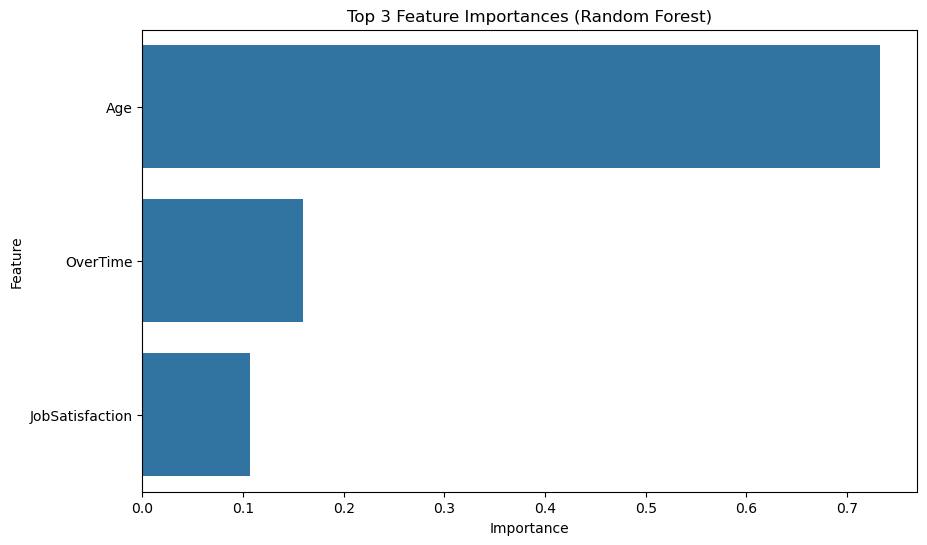

In [116]:
feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model.feature_importances_})
feat_imp = feat_imp.sort_values('Importance', ascending=False).head(3)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp)
plt.title('Top 3 Feature Importances (Random Forest)')
plt.show()

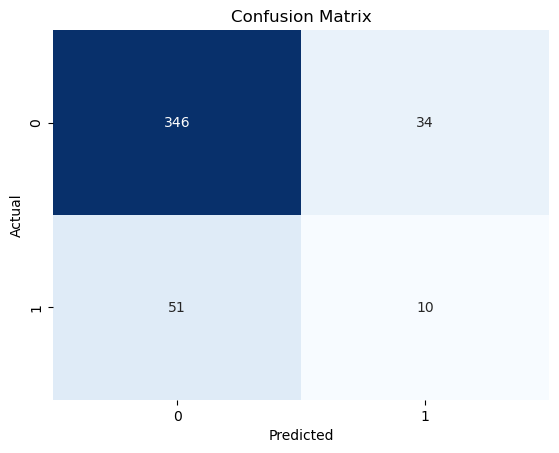

In [118]:
from sklearn.metrics import ConfusionMatrixDisplay

# Plot Confusion Matrix Heatmap
def plot_conf_matrix(y_test, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


# For Random Forest
plot_conf_matrix(y_test, y_pred_rf)

In [120]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm.ravel()

print(f"True Positives: {tp}")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")

True Positives: 10
True Negatives: 346
False Positives: 34
False Negatives: 51


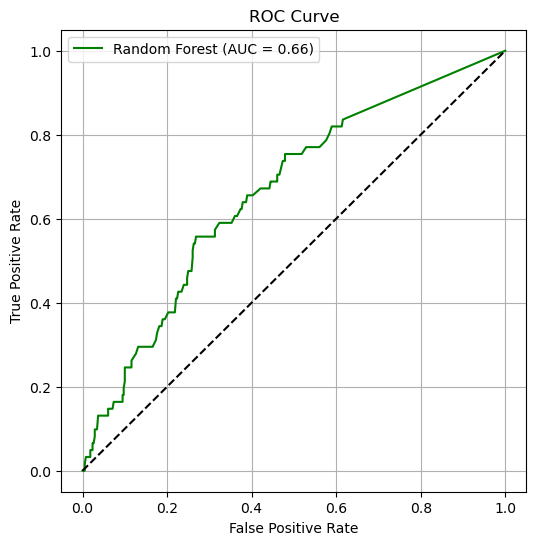

In [104]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities
y_probs = rf_model.predict_proba(X_test)[:, 1]  # Probabilities for class 1

# Compute ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

# Plot
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.2f})", color='green')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line = random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()